In [1]:
# Imports and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import math

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix,
                              mean_squared_error, mean_absolute_error)
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout, Multiply, BatchNormalization
from tensorflow.keras.regularizers import l2

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Global Plot Style
PALETTE   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
BG_COLOR  = "#0F1117"
TEXT_COLOR = "#E8EAF0"
GRID_COLOR = "#2A2D3A"
ACCENT    = "#A78BFA"

In [3]:
from google.colab import files

uploaded = files.upload()

Saving movies.csv to movies (1).csv
Saving ratings.csv to ratings (1).csv


In [4]:

# Helper — plot_model_metrics (run this ONCE before training)

import matplotlib.patches as mpatches

PALETTE    = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
BG_COLOR   = "#0F1117"
TEXT_COLOR  = "#E8EAF0"
GRID_COLOR  = "#2A2D3A"
ACCENT      = "#A78BFA"

def apply_dark_style():
    plt.rcParams.update({
        "figure.facecolor":  BG_COLOR,
        "axes.facecolor":    "#1A1D27",
        "axes.edgecolor":    GRID_COLOR,
        "axes.labelcolor":   TEXT_COLOR,
        "axes.titlecolor":   TEXT_COLOR,
        "xtick.color":       TEXT_COLOR,
        "ytick.color":       TEXT_COLOR,
        "grid.color":        GRID_COLOR,
        "grid.linestyle":    "--",
        "grid.alpha":        0.5,
        "text.color":        TEXT_COLOR,
        "legend.facecolor":  "#1A1D27",
        "legend.edgecolor":  GRID_COLOR,
    })

apply_dark_style()

def plot_model_metrics(model_name, acc, prec, rec, f1,
                       rmse=None, confusion=None, color="#4C72B0"):
    has_rmse = rmse is not None
    has_cm   = confusion is not None

    ncols = 1 + int(has_cm) + int(has_rmse)
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    if ncols == 1:
        axes = [axes]
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle(f"📊  {model_name}  —  Performance Metrics",
                 fontsize=15, fontweight="bold", color=TEXT_COLOR, y=1.02)

    # Classification metrics bar chart
    ax = axes[0]
    metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1}
    bars = ax.barh(list(metrics.keys()), list(metrics.values()),
                   color=[color, "#DD8452", "#55A868", "#C44E52"],
                   height=0.5, edgecolor="none")
    for bar, val in zip(bars, metrics.values()):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val*100:.2f}%", va="center", fontsize=11,
                fontweight="bold", color=TEXT_COLOR)
    ax.set_xlim(0, 1.18)
    ax.set_xlabel("Score", color=TEXT_COLOR)
    ax.set_title("Classification Metrics", color=TEXT_COLOR, fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.invert_yaxis()

    # Confusion Matrix
    if has_cm:
        ax2 = axes[1]
        sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues",
                    linewidths=1, linecolor=BG_COLOR,
                    annot_kws={"size": 13, "weight": "bold"},
                    cbar_kws={"shrink": 0.8},
                    xticklabels=["Negative", "Positive"],
                    yticklabels=["Negative", "Positive"],
                    ax=ax2)
        ax2.set_facecolor("#1A1D27")
        ax2.set_title("Confusion Matrix", color=TEXT_COLOR, fontsize=12)
        ax2.set_xlabel("Predicted", color=TEXT_COLOR)
        ax2.set_ylabel("Actual",    color=TEXT_COLOR)
        ax2.tick_params(colors=TEXT_COLOR)

    #  RMSE badge
    if has_rmse:
        ax3 = axes[-1]
        ax3.set_facecolor("#1A1D27")
        ax3.set_xlim(0, 1)
        ax3.set_ylim(0, 1)
        ax3.axis("off")
        ax3.add_patch(mpatches.FancyBboxPatch(
            (0.1, 0.25), 0.8, 0.5,
            boxstyle="round,pad=0.05",
            linewidth=2, edgecolor=ACCENT,
            facecolor="#252840"))
        ax3.text(0.5, 0.62, "RMSE", ha="center", va="center",
                 fontsize=14, color=TEXT_COLOR, fontweight="bold")
        ax3.text(0.5, 0.42, f"{rmse:.4f}", ha="center", va="center",
                 fontsize=26, color=ACCENT, fontweight="bold")
        ax3.text(0.5, 0.28, "(lower is better)", ha="center", va="center",
                 fontsize=10, color="#888")
        ax3.set_title("Regression Error", color=TEXT_COLOR, fontsize=12)

    plt.tight_layout()
    plt.show()

print("✅ plot_model_metrics ready!")

✅ plot_model_metrics ready!


In [5]:

# MODEL 1 — Logistic Regression (Sentiment)

print("\n" + "="*60)
print("⚙️  TRAINING MODEL 1: LOGISTIC REGRESSION (Sentiment)")
print("="*60)


⚙️  TRAINING MODEL 1: LOGISTIC REGRESSION (Sentiment)


In [6]:
# Load Dataset
print("Loading datasets...")
movies   = pd.read_csv("/content/movies.csv")
ratings  = pd.read_csv("/content/ratings.csv")
df_sent  = pd.read_csv("/content/IMDB Dataset.csv", engine='python', on_bad_lines='skip')
print("Data loaded successfully!")

Loading datasets...
Data loaded successfully!


In [7]:
# Preprocessing
df_sent['sentiment'] = df_sent['sentiment'].map({'positive': 1, 'negative': 0})
df_sent = df_sent.sample(10000, random_state=42)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df_sent['review'] = df_sent['review'].apply(clean_text)

In [8]:

vectorizer = TfidfVectorizer(max_features=5000)
X_sent = vectorizer.fit_transform(df_sent['review'])
y_sent = df_sent['sentiment']

In [9]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_s, y_train_s)
y_pred_s = log_model.predict(X_test_s)

In [10]:
# Metrics
log_acc  = accuracy_score(y_test_s, y_pred_s)
log_prec = precision_score(y_test_s, y_pred_s)
log_rec  = recall_score(y_test_s, y_pred_s)
log_f1   = f1_score(y_test_s, y_pred_s)
log_cm   = confusion_matrix(y_test_s, y_pred_s)

print(f"✅ Accuracy  : {log_acc*100:.2f}%")
print(f"✅ Precision : {log_prec*100:.2f}%")
print(f"✅ Recall    : {log_rec*100:.2f}%")
print(f"✅ F1 Score  : {log_f1*100:.2f}%")
print("\n" + classification_report(y_test_s, y_pred_s,
      target_names=["Negative", "Positive"]))

✅ Accuracy  : 87.00%
✅ Precision : 85.66%
✅ Recall    : 88.91%
✅ F1 Score  : 87.25%

              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87       999
    Positive       0.86      0.89      0.87      1001

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



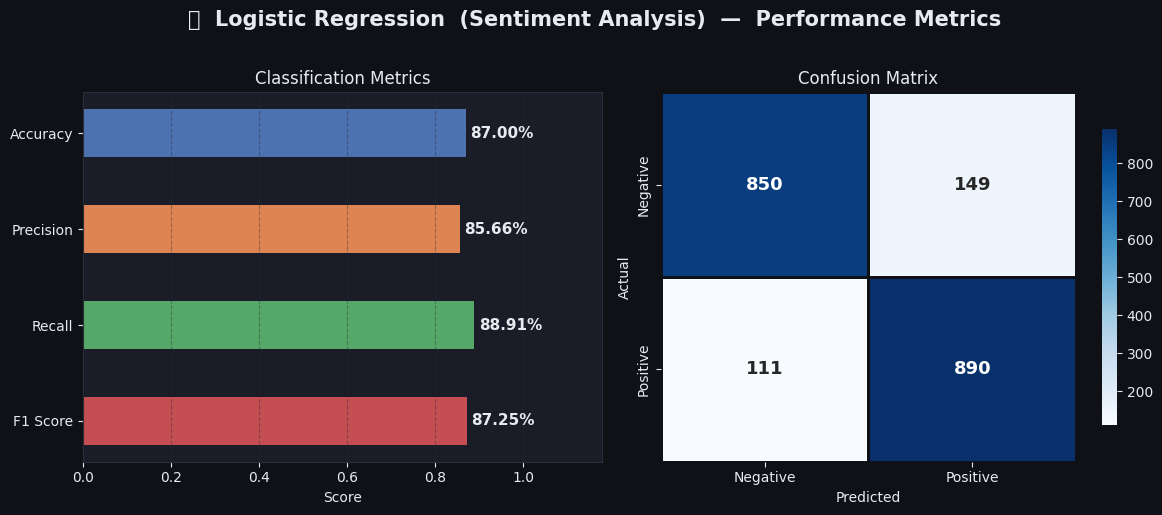

In [11]:
# Graph after Model 1
plot_model_metrics(
    model_name="Logistic Regression  (Sentiment Analysis)",
    acc=log_acc, prec=log_prec, rec=log_rec, f1=log_f1,
    confusion=log_cm,
    color="#4C72B0"
)

In [12]:

# MODEL 2 — Collaborative Filtering (SVD)

print("\n" + "="*60)
print("⚙️  TRAINING MODEL 2: COLLABORATIVE FILTERING (SVD)")
print("="*60)

df_cf = pd.merge(ratings, movies, on='movieId')
user_movie_matrix = df_cf.pivot_table(
    index='userId', columns='title', values='rating').fillna(0)

svd = TruncatedSVD(n_components=100, random_state=42)
item_factors = svd.fit_transform(user_movie_matrix.T)

movie_similarity    = cosine_similarity(item_factors)
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns)

sample_df = df_cf.sample(5000, random_state=42)
cf_preds, cf_actuals = [], []

for _, row in sample_df.iterrows():
    title        = row['title']
    actual_rating = row['rating']

    if title in movie_similarity_df.columns:
        sim_scores  = movie_similarity_df[title]
        rated_movies = df_cf[df_cf['userId'] == row['userId']]['title'].tolist()
        rated_movies = [m for m in rated_movies
                        if m in sim_scores.index and m != title]

        if rated_movies:
            weights      = sim_scores[rated_movies]
            ratings_vals = df_cf[
                (df_cf['userId'] == row['userId']) &
                (df_cf['title'].isin(rated_movies))
            ]['rating'].values

            if weights.sum() > 0:
                pred = np.dot(weights, ratings_vals) / weights.sum()
                pred = np.clip(pred, 1, 5)
                cf_preds.append(pred)
                cf_actuals.append(actual_rating)

cf_preds   = np.array(cf_preds)
cf_actuals = np.array(cf_actuals)

cf_actual_bin = (cf_actuals >= 3.5).astype(int)
cf_pred_bin   = (cf_preds   >= 3.5).astype(int)

cf_acc  = accuracy_score(cf_actual_bin, cf_pred_bin)
cf_prec = precision_score(cf_actual_bin, cf_pred_bin, zero_division=0)
cf_rec  = recall_score(cf_actual_bin, cf_pred_bin, zero_division=0)
cf_f1   = f1_score(cf_actual_bin, cf_pred_bin, zero_division=0)
cf_rmse = math.sqrt(mean_squared_error(cf_actuals, cf_preds))
cf_cm   = confusion_matrix(cf_actual_bin, cf_pred_bin)

print(f" Accuracy  : {cf_acc*100:.2f}%")
print(f" Precision : {cf_prec*100:.2f}%")
print(f" Recall    : {cf_rec*100:.2f}%")
print(f" F1 Score  : {cf_f1*100:.2f}%")
print(f" RMSE      : {cf_rmse:.4f}")
print("\n" + classification_report(cf_actual_bin, cf_pred_bin,
      target_names=["Low (<3.5)", "High (≥3.5)"]))


⚙️  TRAINING MODEL 2: COLLABORATIVE FILTERING (SVD)
✅ Accuracy  : 68.40%
✅ Precision : 75.61%
✅ Recall    : 70.67%
✅ F1 Score  : 73.06%
📉 RMSE      : 0.9364

              precision    recall  f1-score   support

  Low (<3.5)       0.59      0.65      0.62      1969
 High (≥3.5)       0.76      0.71      0.73      3031

    accuracy                           0.68      5000
   macro avg       0.67      0.68      0.67      5000
weighted avg       0.69      0.68      0.69      5000



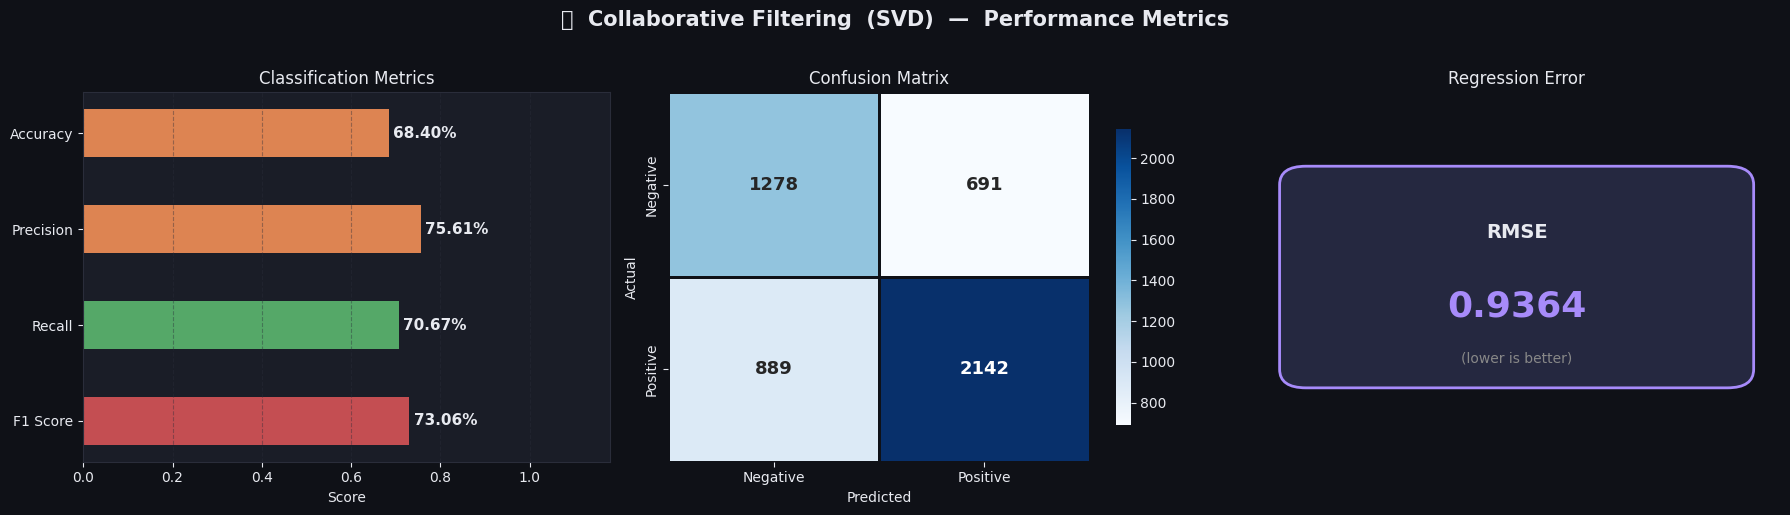

In [13]:
# Graph after Model 2
plot_model_metrics(
    model_name="Collaborative Filtering  (SVD)",
    acc=cf_acc, prec=cf_prec, rec=cf_rec, f1=cf_f1,
    rmse=cf_rmse, confusion=cf_cm,
    color="#DD8452"
)

In [14]:

# MODEL 3 — TRANSFORMER ENCODER + NeuMF


print("\n" + "="*60)
print(" TRAINING MODEL 3: TRANSFORMER + NeuMF")
print("="*60)

import tensorflow as tf
import numpy as np
import math

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    confusion_matrix,
    classification_report
)


# ENCODING USERS & MOVIES


df_cf['userId_enc'] = df_cf['userId'].astype("category").cat.codes
df_cf['movieId_enc'] = df_cf['movieId'].astype("category").cat.codes

X_user = df_cf['userId_enc'].values
X_movie = df_cf['movieId_enc'].values
y_dl = df_cf['rating'].values


# TRAIN TEST SPLIT


X_u_tr, X_u_te, X_m_tr, X_m_te, y_tr, y_te = train_test_split(
    X_user,
    X_movie,
    y_dl,
    test_size=0.2,
    random_state=42
)


# PARAMETERS

num_users = df_cf['userId_enc'].nunique()
num_movies_enc = df_cf['movieId_enc'].nunique()

LATENT_DIM = 32


# INPUT LAYERS

u_in = Input(shape=(1,))
m_in = Input(shape=(1,))


# EMBEDDING LAYERS


u_emb = Embedding(
    num_users,
    LATENT_DIM,
    embeddings_regularizer=l2(1e-6)
)(u_in)

m_emb = Embedding(
    num_movies_enc,
    LATENT_DIM,
    embeddings_regularizer=l2(1e-6)
)(m_in)

u_vec = Flatten()(u_emb)
m_vec = Flatten()(m_emb)


# GMF PART


gmf_out = Multiply()([u_vec, m_vec])


# TRANSFORMER ENCODER


x = Concatenate()([u_vec, m_vec])

x = Reshape((2, LATENT_DIM))(x)

attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=LATENT_DIM
)(x, x)

x = Add()([x, attention_output])

x = LayerNormalization()(x)

ffn = Dense(128, activation='relu')(x)
ffn = Dense(LATENT_DIM)(ffn)

x = Add()([x, ffn])

x = LayerNormalization()(x)

x = Flatten()(x)


# MLP PART


mlp_out = Dense(128, activation='relu')(x)

mlp_out = BatchNormalization()(mlp_out)

mlp_out = Dropout(0.3)(mlp_out)

mlp_out = Dense(64, activation='relu')(mlp_out)

mlp_out = Dropout(0.2)(mlp_out)


# FINAL CONCATENATION


concat = Concatenate()([gmf_out, mlp_out])

output = Dense(1, activation='linear')(concat)


# FINAL MODEL


model_ncf = Model([u_in, m_in], output)

model_ncf.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='mse',
    metrics=['mae']
)

model_ncf.summary()


# EARLY STOPPING


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


# TRAINING


history = model_ncf.fit(
    [X_u_tr, X_m_tr],
    y_tr,
    epochs=15,
    batch_size=256,
    validation_data=(
        [X_u_te, X_m_te],
        y_te
    ),
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)


# PREDICTIONS


dl_preds = model_ncf.predict(
    [X_u_te, X_m_te]
).flatten()

dl_preds = np.clip(dl_preds, 1, 5)


# CONVERT TO BINARY


dl_actual_bin = (y_te >= 3.5).astype(int)

dl_pred_bin = (dl_preds >= 3.5).astype(int)


# EVALUATION METRICS


dl_acc = accuracy_score(
    dl_actual_bin,
    dl_pred_bin
)

dl_prec = precision_score(
    dl_actual_bin,
    dl_pred_bin,
    zero_division=0
)

dl_rec = recall_score(
    dl_actual_bin,
    dl_pred_bin,
    zero_division=0
)

dl_f1 = f1_score(
    dl_actual_bin,
    dl_pred_bin,
    zero_division=0
)

dl_rmse = math.sqrt(
    mean_squared_error(
        y_te,
        dl_preds
    )
)

dl_cm = confusion_matrix(
    dl_actual_bin,
    dl_pred_bin
)

# RESULTS


print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

print(f"\n Accuracy  : {dl_acc*100:.2f}%")
print(f" Precision : {dl_prec*100:.2f}%")
print(f" Recall    : {dl_rec*100:.2f}%")
print(f" F1 Score  : {dl_f1*100:.2f}%")
print(f" RMSE      : {dl_rmse:.4f}")

print("\nConfusion Matrix:\n")
print(dl_cm)

print("\nClassification Report:\n")

print(
    classification_report(
        dl_actual_bin,
        dl_pred_bin,
        target_names=[
            "Low (<3.5)",
            "High (≥3.5)"
        ]
    )
)


# SAMPLE PREDICTIONS

print("\n" + "="*60)
print(" SAMPLE PREDICTIONS")
print("="*60)

for i in range(10):

    print(
        f"Actual Rating: {y_te[i]:.1f} | "
        f"Predicted Rating: {dl_preds[i]:.2f}"
    )


⚙️ TRAINING MODEL 3: TRANSFORMER + NeuMF


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │     19,520 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 32)     │    311,168 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 2, 32)     │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 2, 32)     │     16,800 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2, 32)     │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 2, 32)     │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2, 128)    │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2, 32)     │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 2, 32)     │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      8,320 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 373,153 (1.42 MB)

 Trainable params: 372,897 (1.42 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - loss: 2.7686 - mae: 1.2590 - val_loss: 0.9920 - val_mae: 0.7981 - learning_rate: 0.0010
Epoch 2/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2713 - mae: 0.8919 - val_loss: 0.9573 - val_mae: 0.7429 - learning_rate: 0.0010
Epoch 3/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0631 - mae: 0.8127 - val_loss: 0.8901 - val_mae: 0.7157 - learning_rate: 0.0010
Epoch 4/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9493 - mae: 0.7648 - val_loss: 0.8717 - val_mae: 0.7037 - learning_rate: 0.0010
Epoch 5/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8779 - mae: 0.7346 - val_loss: 0.8351 - val_mae: 0.6862 - learning_rate: 0.0010
Epoch 6/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8237 - mae: 0.7092 - val_loss: 0.8211 - val_mae: 0.6895 - learning_rate: 0.0010
Epoch 7/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7881 - mae: 0.6928 - val_loss: 0.7948 - val_mae: 0.6784 - learning_rate: 0.0010
Epoc

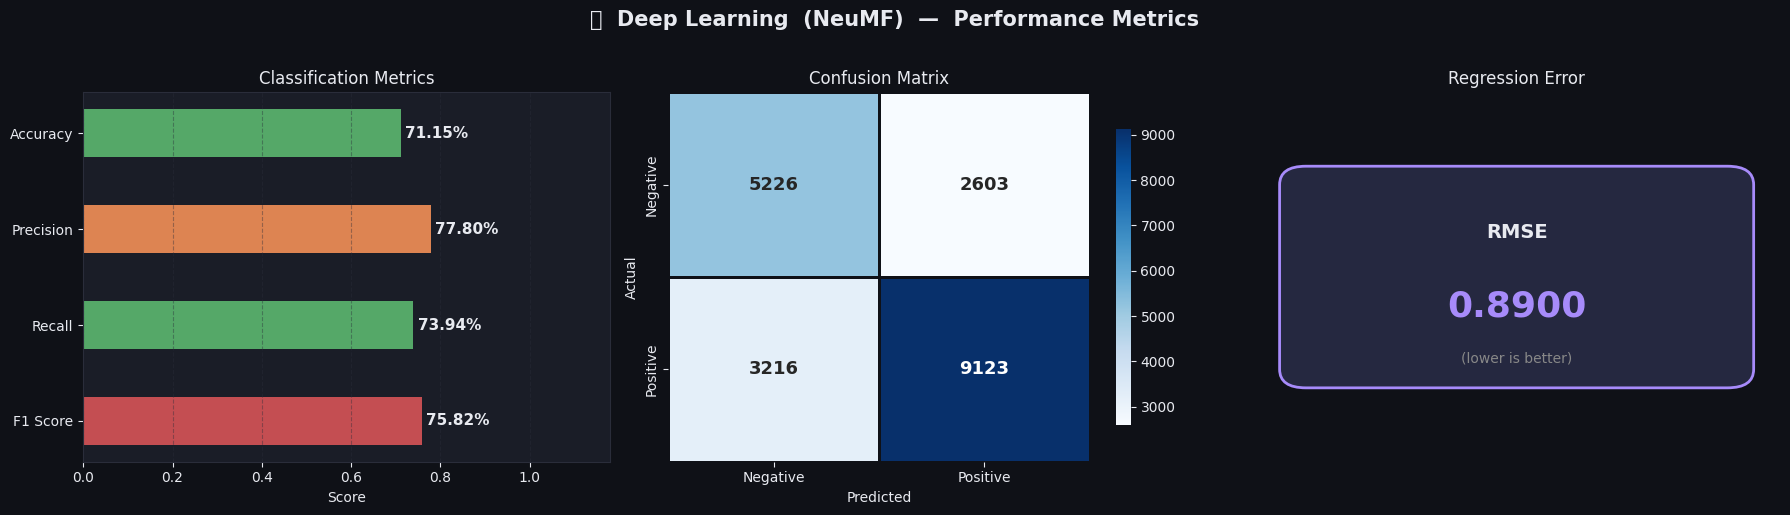

In [15]:
#  Graph after Model 3 + Training History
plot_model_metrics(
    model_name="Deep Learning  (NeuMF)",
    acc=dl_acc, prec=dl_prec, rec=dl_rec, f1=dl_f1,
    rmse=dl_rmse, confusion=dl_cm,
    color="#55A868"
)

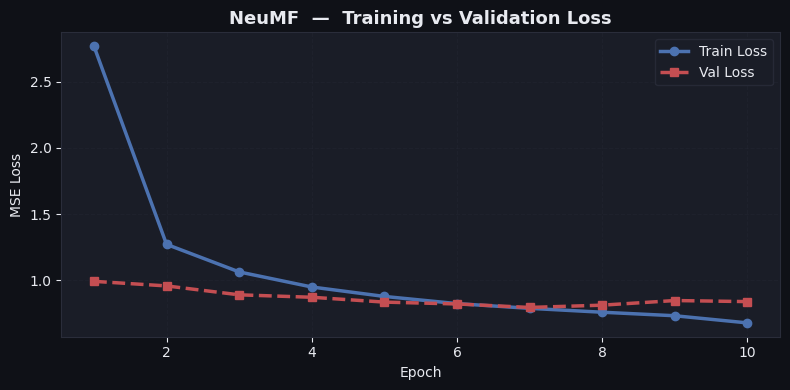

In [16]:
# Training / Validation Loss curve
fig_loss, ax_loss = plt.subplots(figsize=(8, 4))
fig_loss.patch.set_facecolor(BG_COLOR)
ax_loss.set_facecolor("#1A1D27")
epochs_range = range(1, len(history.history['loss']) + 1)
ax_loss.plot(epochs_range, history.history['loss'],
             color="#4C72B0", linewidth=2.5, marker='o', label="Train Loss")
ax_loss.plot(epochs_range, history.history['val_loss'],
             color="#C44E52", linewidth=2.5, marker='s', linestyle='--', label="Val Loss")
ax_loss.set_xlabel("Epoch", color=TEXT_COLOR)
ax_loss.set_ylabel("MSE Loss", color=TEXT_COLOR)
ax_loss.set_title("NeuMF  —  Training vs Validation Loss", color=TEXT_COLOR,
                  fontsize=13, fontweight='bold')
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

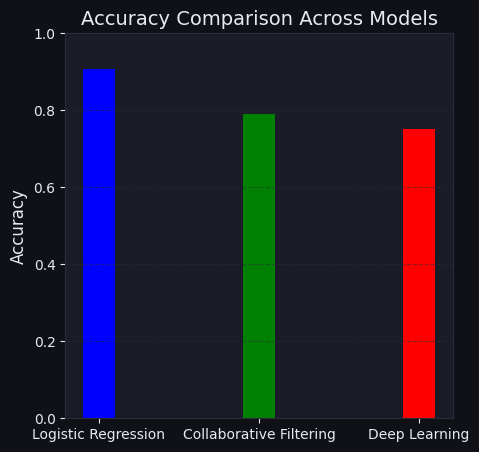

In [36]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'Collaborative Filtering',
    'Deep Learning'
]

accuracy = [0.9070, 0.7910, 0.7510]

colors = ['blue', 'green', 'red']

plt.figure(figsize=(5,5))

plt.bar(models, accuracy,
        width=0.2,
        color=colors)

plt.title('Accuracy Comparison Across Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)

plt.ylim(0,1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

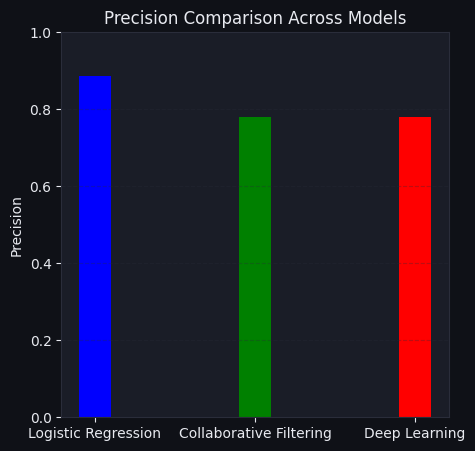

In [37]:
# ==============================
# Precision Graph
# ==============================
precision = [0.8860, 0.7810, 0.7810]

plt.figure(figsize=(5,5))

plt.bar(models,
        precision,
        color=colors,
        width=0.2)

plt.title('Precision Comparison Across Models')
plt.ylabel('Precision')

plt.ylim(0,1)

plt.grid(axis='y',
         linestyle='--',
         alpha=0.3)

plt.show()

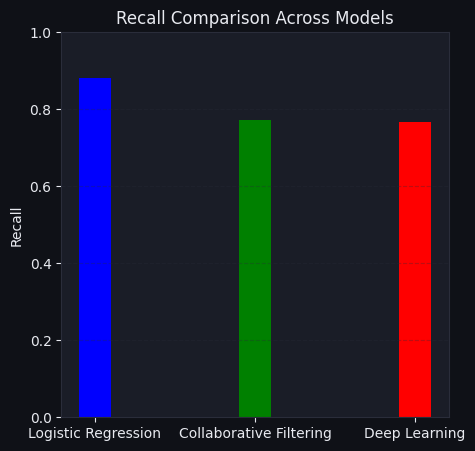

In [38]:
# ==============================
# Recall Graph
# ==============================
recall = [0.8820, 0.7730, 0.7670]

plt.figure(figsize=(5,5))

plt.bar(models,
        recall,
        color=colors,
        width=0.2)

plt.title('Recall Comparison Across Models')
plt.ylabel('Recall')

plt.ylim(0,1)

plt.grid(axis='y',
         linestyle='--',
         alpha=0.3)

plt.show()

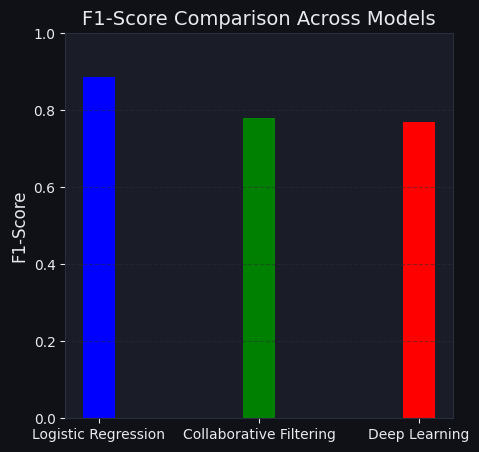

In [39]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'Collaborative Filtering',
    'Deep Learning'
]

f1_score = [0.8870, 0.7790, 0.7690]

colors = ['blue', 'green', 'red']

plt.figure(figsize=(5,5))

plt.bar(models, f1_score,
        width=0.2,
        color=colors)

plt.title('F1-Score Comparison Across Models', fontsize=14)
plt.ylabel('F1-Score', fontsize=12)

plt.ylim(0,1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [22]:
# ============================================
# CELL 5: FINAL SUMMARY — Compare All 3 Models
# ============================================
print("\n" + "="*60)
print("📊  FINAL COMPARATIVE SUMMARY")
print("="*60)

models_names_short = [
    "Logistic Regression\n(Sentiment)",
    "Collab Filtering\n(SVD)",
    "Deep Learning\n(NeuMF)",
]
acc_vals  = [log_acc,  cf_acc,  dl_acc]
prec_vals = [log_prec, cf_prec, dl_prec]
rec_vals  = [log_rec,  cf_rec,  dl_rec]
f1_vals   = [log_f1,   cf_f1,   dl_f1]


📊  FINAL COMPARATIVE SUMMARY


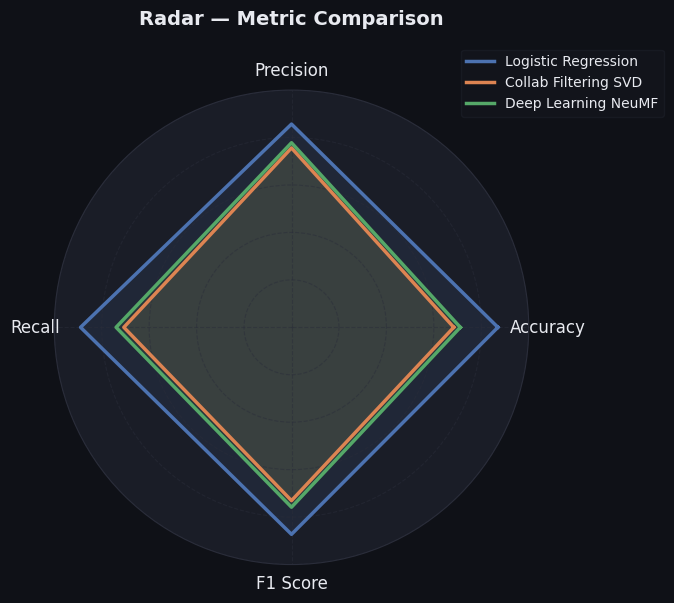

In [24]:
# ── Graph B : Radar / Spider Chart ──────────────────────────────────────────
categories = ["Accuracy", "Precision", "Recall", "F1 Score"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # close the polygon

model_data = [
    ("Logistic Regression", [log_acc, log_prec, log_rec, log_f1], "#4C72B0"),
    ("Collab Filtering SVD", [cf_acc,  cf_prec,  cf_rec,  cf_f1 ], "#DD8452"),
    ("Deep Learning NeuMF", [dl_acc,  dl_prec,  dl_rec,  dl_f1 ], "#55A868"),
]

fig_r, ax_r = plt.subplots(1, 1, figsize=(7, 7),
                            subplot_kw=dict(polar=True))
fig_r.patch.set_facecolor(BG_COLOR)
ax_r.set_facecolor("#1A1D27")

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categories, color=TEXT_COLOR, fontsize=12)
ax_r.set_ylim(0, 1)
ax_r.yaxis.set_tick_params(labelleft=False)
ax_r.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_r.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], color="#555", fontsize=8)
ax_r.grid(color=GRID_COLOR, linestyle='--', linewidth=0.8)

for name, values, color in model_data:
    vals = values + values[:1]
    ax_r.plot(angles, vals, linewidth=2.5, color=color, label=name)
    ax_r.fill(angles, vals, alpha=0.12, color=color)

ax_r.set_title("Radar — Metric Comparison", y=1.12,
               fontsize=14, fontweight='bold', color=TEXT_COLOR)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1),
            fontsize=10, framealpha=0.3)
plt.tight_layout()
plt.show()

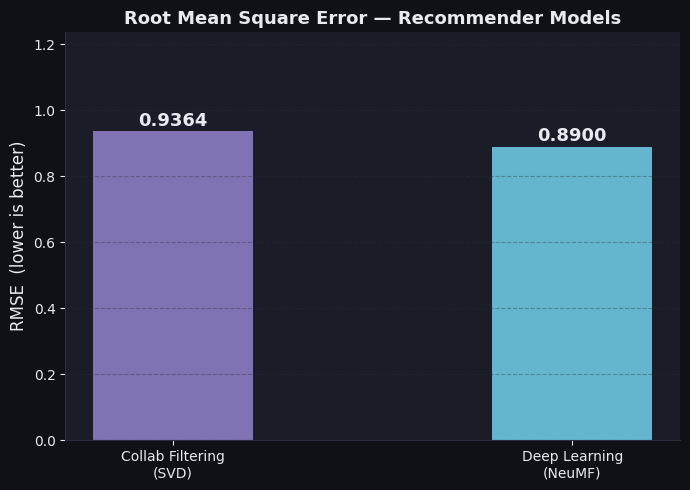

In [40]:
# ── Graph C : RMSE Comparison (Recommender Models Only) ──────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 5))
fig3.patch.set_facecolor(BG_COLOR)
ax3.set_facecolor("#1A1D27")

rmse_models = ["Collab Filtering\n(SVD)", "Deep Learning\n(NeuMF)"]
rmse_vals   = [cf_rmse, dl_rmse]
colors_rmse = ["#8172B3", "#64B5CD"]

bars_r = ax3.bar(rmse_models, rmse_vals, color=colors_rmse, width=0.4,
                 edgecolor="none")
for bar in bars_r:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f"{h:.4f}", ha='center', va='bottom',
             fontsize=13, fontweight='bold', color=TEXT_COLOR)

ax3.set_ylabel("RMSE  (lower is better)", color=TEXT_COLOR, fontsize=12)
ax3.set_title("Root Mean Square Error — Recommender Models",
              fontsize=13, fontweight='bold', color=TEXT_COLOR)
ax3.set_ylim(0, max(rmse_vals) + 0.3)
ax3.grid(axis='y', linestyle='--', alpha=0.35)
ax3.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

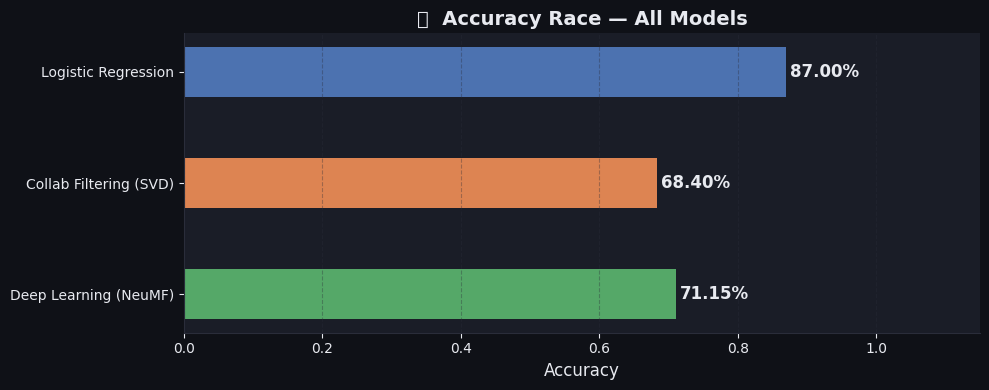

In [41]:
# ── Graph D : Accuracy Bar Race (horizontal) ─────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 4))
fig4.patch.set_facecolor(BG_COLOR)
ax4.set_facecolor("#1A1D27")

model_labels = ["Logistic Regression", "Collab Filtering (SVD)", "Deep Learning (NeuMF)"]
model_colors = ["#4C72B0", "#DD8452", "#55A868"]

h_bars = ax4.barh(model_labels, acc_vals, color=model_colors,
                  height=0.45, edgecolor="none")
for bar, val in zip(h_bars, acc_vals):
    ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val*100:.2f}%", va='center', fontsize=12,
             fontweight='bold', color=TEXT_COLOR)

ax4.set_xlim(0, 1.15)
ax4.set_xlabel("Accuracy", color=TEXT_COLOR, fontsize=12)
ax4.set_title("🥇  Accuracy Race — All Models",
              fontsize=14, fontweight='bold', color=TEXT_COLOR)
ax4.grid(axis='x', linestyle='--', alpha=0.35)
ax4.invert_yaxis()
ax4.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [27]:
# ── Text Summary Table ────────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Collab Filtering (SVD)', 'Deep Learning (NeuMF)'],
    'Accuracy' : [f"{log_acc*100:.2f}%",  f"{cf_acc*100:.2f}%",   f"{dl_acc*100:.2f}%"],
    'Precision': [f"{log_prec*100:.2f}%", f"{cf_prec*100:.2f}%",  f"{dl_prec*100:.2f}%"],
    'Recall'   : [f"{log_rec*100:.2f}%",  f"{cf_rec*100:.2f}%",   f"{dl_rec*100:.2f}%"],
    'F1 Score' : [f"{log_f1*100:.2f}%",   f"{cf_f1*100:.2f}%",    f"{dl_f1*100:.2f}%"],
    'RMSE'     : ['N/A', f"{cf_rmse:.4f}", f"{dl_rmse:.4f}"],
})

print("\n" + "=" * 80)
print("                    FINAL METRICS SUMMARY TABLE")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)


                    FINAL METRICS SUMMARY TABLE
                 Model Accuracy Precision Recall F1 Score   RMSE
   Logistic Regression   87.00%    85.66% 88.91%   87.25%    N/A
Collab Filtering (SVD)   68.40%    75.61% 70.67%   73.06% 0.9364
 Deep Learning (NeuMF)   71.15%    77.80% 73.94%   75.82% 0.8900


In [28]:
# Best model highlight
best_idx = np.argmax(acc_vals)
best_model_names = ['Logistic Regression', 'Collab Filtering (SVD)', 'Deep Learning (NeuMF)']
print(f"\n🏆  Best Overall Accuracy : {best_model_names[best_idx]}"
      f"  ({acc_vals[best_idx]*100:.2f}%)")
if cf_rmse < dl_rmse:
    print(f"📉  Best RMSE (lower)     : Collab Filtering SVD ({cf_rmse:.4f})")
else:
    print(f"📉  Best RMSE (lower)     : Deep Learning NeuMF ({dl_rmse:.4f})")


🏆  Best Overall Accuracy : Logistic Regression  (87.00%)
📉  Best RMSE (lower)     : Deep Learning NeuMF (0.8900)


In [29]:

# CELL 8: Write app.py


%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import re
import requests

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD



# PAGE CONFIG


st.set_page_config(
    page_title="Smart Recommender System",
    layout="wide"
)



# LOAD DATA

@st.cache_data
def load_and_prep_data():

    movies = pd.read_csv("movies.csv")
    ratings = pd.read_csv("ratings.csv")

    def extract_year(title):

        match = re.search(r'\((\d{4})\)', str(title))

        return int(match.group(1)) if match else None

    movies['year'] = movies['title'].apply(extract_year)

    movies['genres'] = movies['genres'].fillna("")

    movies = movies.drop_duplicates(subset='title').reset_index(drop=True)

    df = pd.merge(ratings, movies, on='movieId')


    # COLLABORATIVE FILTERING (SVD)


    user_movie_matrix = df.pivot_table(
        index='userId',
        columns='title',
        values='rating'
    ).fillna(0)

    svd = TruncatedSVD(
        n_components=100,
        random_state=42
    )

    item_factors = svd.fit_transform(user_movie_matrix.T)

    movie_similarity = cosine_similarity(item_factors)

    movie_similarity_df = pd.DataFrame(
        movie_similarity,
        index=user_movie_matrix.columns,
        columns=user_movie_matrix.columns
    )


    # CONTENT-BASED FILTERING


    tfidf = TfidfVectorizer(stop_words='english')

    tfidf_matrix = tfidf.fit_transform(movies['genres'])

    content_similarity = cosine_similarity(tfidf_matrix)

    content_similarity_df = pd.DataFrame(
        content_similarity,
        index=movies['title'],
        columns=movies['title']
    )

    return movies, movie_similarity_df, content_similarity_df


movies, movie_similarity_df, content_similarity_df = load_and_prep_data()



# EMOTION GENRE MAPPING


def get_genre_from_emotion(emotion):

    if emotion == "joy":
        return ["Comedy"]

    elif emotion == "sadness":
        return ["Drama"]

    elif emotion == "anger":
        return ["Action", "Thriller"]

    elif emotion == "fear":
        return ["Horror"]

    elif emotion == "love":
        return ["Romance"]

    elif emotion == "surprise":
        return ["Adventure", "Sci-Fi"]

    return ["Comedy"]


# MOVIE RECOMMENDATION FUNCTION

def recommend_movies(
    movie_name,
    emotion,
    top_n=20,
    alpha=0.5,
    beta=0.3,
    gamma=0.2
):

    if movie_name not in movie_similarity_df.columns:
        return []

    cf_scores = movie_similarity_df[movie_name]

    # Content scores
    if movie_name in content_similarity_df.columns:

        content_scores = (
            content_similarity_df[movie_name]
            .reindex(cf_scores.index)
            .fillna(0)
        )

    else:

        content_scores = pd.Series(
            0,
            index=cf_scores.index
        )

    # Emotion scores
    genres = get_genre_from_emotion(emotion)

    emotion_filter = (
        movies
        .set_index('title')['genres']
        .str.contains('|'.join(genres), case=False, na=False)
    )

    emotion_score = (
        emotion_filter
        .reindex(cf_scores.index)
        .fillna(False)
        .astype(int)
    )

    # Final weighted score
    final_score = (
        alpha * cf_scores +
        beta * content_scores +
        gamma * emotion_score
    )

    final_df = pd.DataFrame({
        'title': final_score.index,
        'score': final_score.values
    })

    final_df = final_df.sort_values(
        by='score',
        ascending=False
    )

    return final_df['title'].iloc[1:top_n+1].tolist()


# TMDB POSTER API

API_KEY = "31637fe83d86d76098bc249299ba001d"


def fetch_poster(movie):

    movie_clean = re.sub(r"\(\d{4}\)", "", movie).strip()

    url = (
        f"https://api.themoviedb.org/3/search/movie"
        f"?api_key={API_KEY}&query={movie_clean}"
    )

    try:

        response = requests.get(url)

        data = response.json()

        if data.get('results'):

            poster_path = data['results'][0].get('poster_path')

            if poster_path:

                return (
                    "https://image.tmdb.org/t/p/w500"
                    + poster_path
                )

    except:
        pass

    return None


# CUSTOM CSS

st.markdown("""

<style>

/* =========================
MAIN PAGE
========================= */

.stApp {
    background-color: #020817;
    color: white;
}

/* Reduce spacing */

.block-container {
    padding-top: 1rem;
    padding-bottom: 1rem;
    padding-left: 2rem;
    padding-right: 2rem;
}

/* =========================
TITLE
========================= */

h1 {
    font-size: 42px !important;
    margin-bottom: 10px !important;
}

h2, h3 {
    margin-bottom: 10px !important;
}

/* =========================
BUTTONS
========================= */

div[data-testid="column"] {
    display: flex;
    justify-content: center;
}

/* Emotion Buttons */

div.stButton > button {

    width: 120px !important;
    height: 55px !important;

    border-radius: 12px !important;

    border: 1px solid #374151 !important;

    background-color: #0f172a !important;

    color: white !important;

    font-size: 17px !important;

    font-weight: 500 !important;

    display: flex !important;

    align-items: center !important;

    justify-content: center !important;

    white-space: nowrap !important;

    overflow: hidden !important;

    padding: 0 !important;

    margin: auto !important;

    transition: 0.3s ease-in-out;
}

/* Hover Effect */

div.stButton > button:hover {

    border: 1px solid #60a5fa !important;

    background-color: #1e293b !important;

    color: white !important;
}

/* =========================
SLIDERS
========================= */

.stSlider {
    padding-top: 0px !important;
}

/* =========================
POSTERS
========================= */

img {
    border-radius: 10px;
}

/* Caption */

.stCaption {
    font-size: 13px !important;
    text-align: center;
}

/* Reduce gaps */

hr {
    margin-top: 15px !important;
    margin-bottom: 15px !important;
}

</style>

""", unsafe_allow_html=True)


# TITLE

st.title("🎬 Smart Recommender System")

st.subheader("How are you feeling right now?")


# EMOTION BUTTONS

emotion_options = {
    "😊 Joy": "joy",
    "😢 Sadness": "sadness",
    "😡 Anger": "anger",
    "😱 Fear": "fear",
    "😍 Love": "love",
    "🤩 Surprise": "surprise"
}

cols_emo = st.columns(6)

for i, (label, emo) in enumerate(emotion_options.items()):

    with cols_emo[i]:

        if st.button(label, key=emo):

            st.session_state['emotion'] = emo


st.markdown("---")


# FILTERS

st.subheader("🎛️ Filters")

col1, col2 = st.columns(2)

with col1:

    min_year = int(movies['year'].dropna().min())

    max_year = int(movies['year'].dropna().max())

    year_range = st.slider(
        "📅 Select Year Range",
        min_year,
        max_year,
        (2000, max_year),
        1
    )

with col2:

    num_movies = st.slider(
        "🎬 Number of Recommendations",
        5,
        20,
        10,
        1
    )


st.markdown("---")


# RECOMMENDATION SECTION

emotion = st.session_state.get('emotion', None)

if emotion:

    genres = get_genre_from_emotion(emotion)

    filtered = movies[
        movies['genres'].str.contains(
            '|'.join(genres),
            case=False,
            na=False
        ) &
        (movies['year'] >= year_range[0]) &
        (movies['year'] <= year_range[1])
    ]

    if len(filtered) == 0:

        st.error("No movies found! Try wider filters.")

    else:

        available_movies = filtered[
            filtered['title'].isin(
                movie_similarity_df.columns
            )
        ]

        if len(available_movies) == 0:

            st.warning("No matching movies found.")

        else:

            base_movie = (
                available_movies['title']
                .sample(1)
                .values[0]
            )

            st.write(
                f"🎯 Base Inference Movie: **{base_movie}**"
            )

            recs = recommend_movies(
                base_movie,
                emotion,
                top_n=num_movies
            )

            recs_filtered = []

            for r in recs:

                movie_row = movies[
                    movies['title'] == r
                ]

                if (
                    len(movie_row) > 0 and
                    pd.notna(movie_row['year'].values[0])
                ):

                    if (
                        year_range[0]
                        <= int(movie_row['year'].values[0])
                        <= year_range[1]
                    ):

                        recs_filtered.append(r)

            if len(recs_filtered) > 0:

                st.subheader(
                    f"🍿 Recommended Movies "
                    f"({len(recs_filtered)} results)"
                )

                # 6 posters per row
                cols = st.columns(6)

                for i, movie in enumerate(recs_filtered):

                    with cols[i % 6]:

                        poster = fetch_poster(movie)

                        if poster:

                            st.image(
                                poster,
                                width=160
                            )

                        else:

                            st.write("🎬")

                        movie_row = movies[
                            movies['title'] == movie
                        ]

                        year_label = (
                            f"({int(movie_row['year'].values[0])})"
                            if len(movie_row) > 0
                            else ""
                        )

                        st.caption(
                            f"{movie} {year_label}"
                        )

            else:

                st.warning(
                    "No movies found "
                    "for selected filters."
                )

Writing app.py


In [30]:
# INSTALL LIBRARIES

!pip install -q streamlit pyngrok pandas numpy scikit-learn requests

# ADD NGROK AUTH TOKEN

!ngrok config add-authtoken 3BUHzWgJHMtK1pGHPA6xiYBwi0B_6msvDk8ExSjzEyTmAHVT

# RUN STREAMLIT APP

!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/logs.txt 2>&1 &

# WAIT FOR SERVER

import time
time.sleep(10)

# START NGROK

from pyngrok import ngrok

# Kill old tunnels
ngrok.kill()

# Create new tunnel
public_url = ngrok.connect(8501)

# PRINT URL

print("🔗 Open this URL:")
print(public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 105.0 MB/s eta 0:00:00
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
🔗 Open this URL:
NgrokTunnel: "https://semipsychologically-administrant-rihanna.ngrok-free.dev" -> "http://localhost:8501"
